<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB
None
   day  month  year  Temperature  RH  Ws  Rain  FFMC  DMC    DC  ISI  BUI  \
0    1      6  2012           29  57

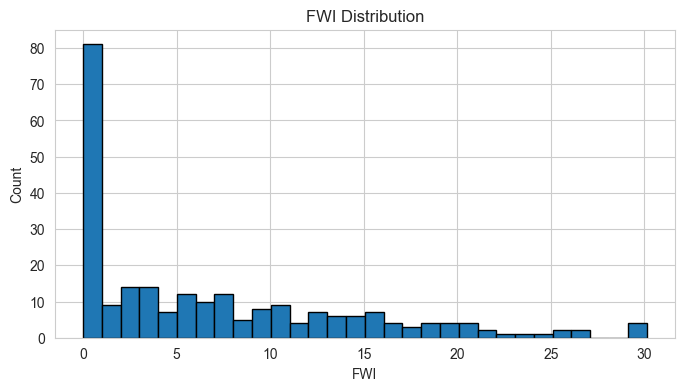

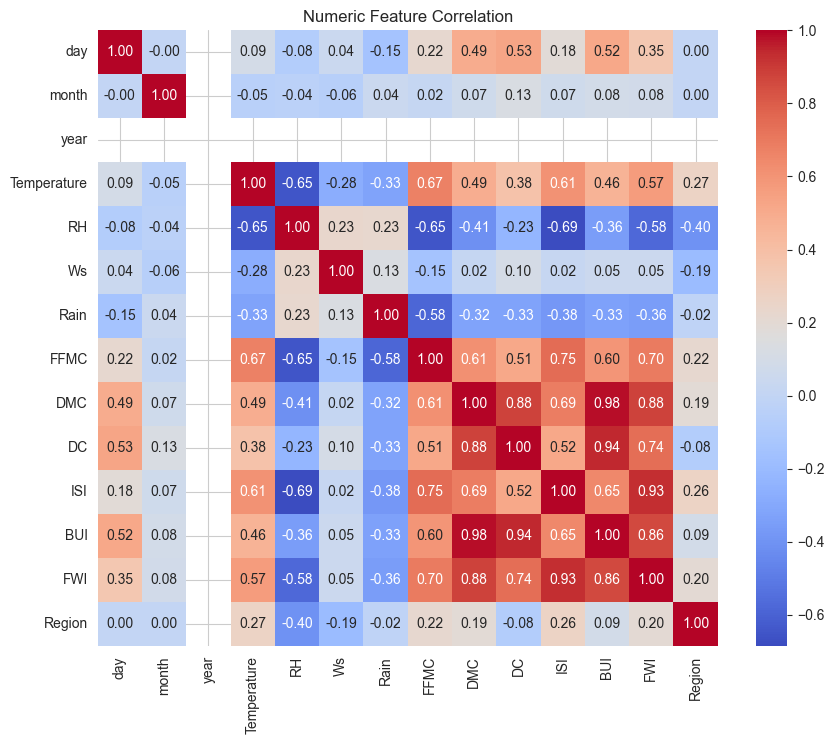

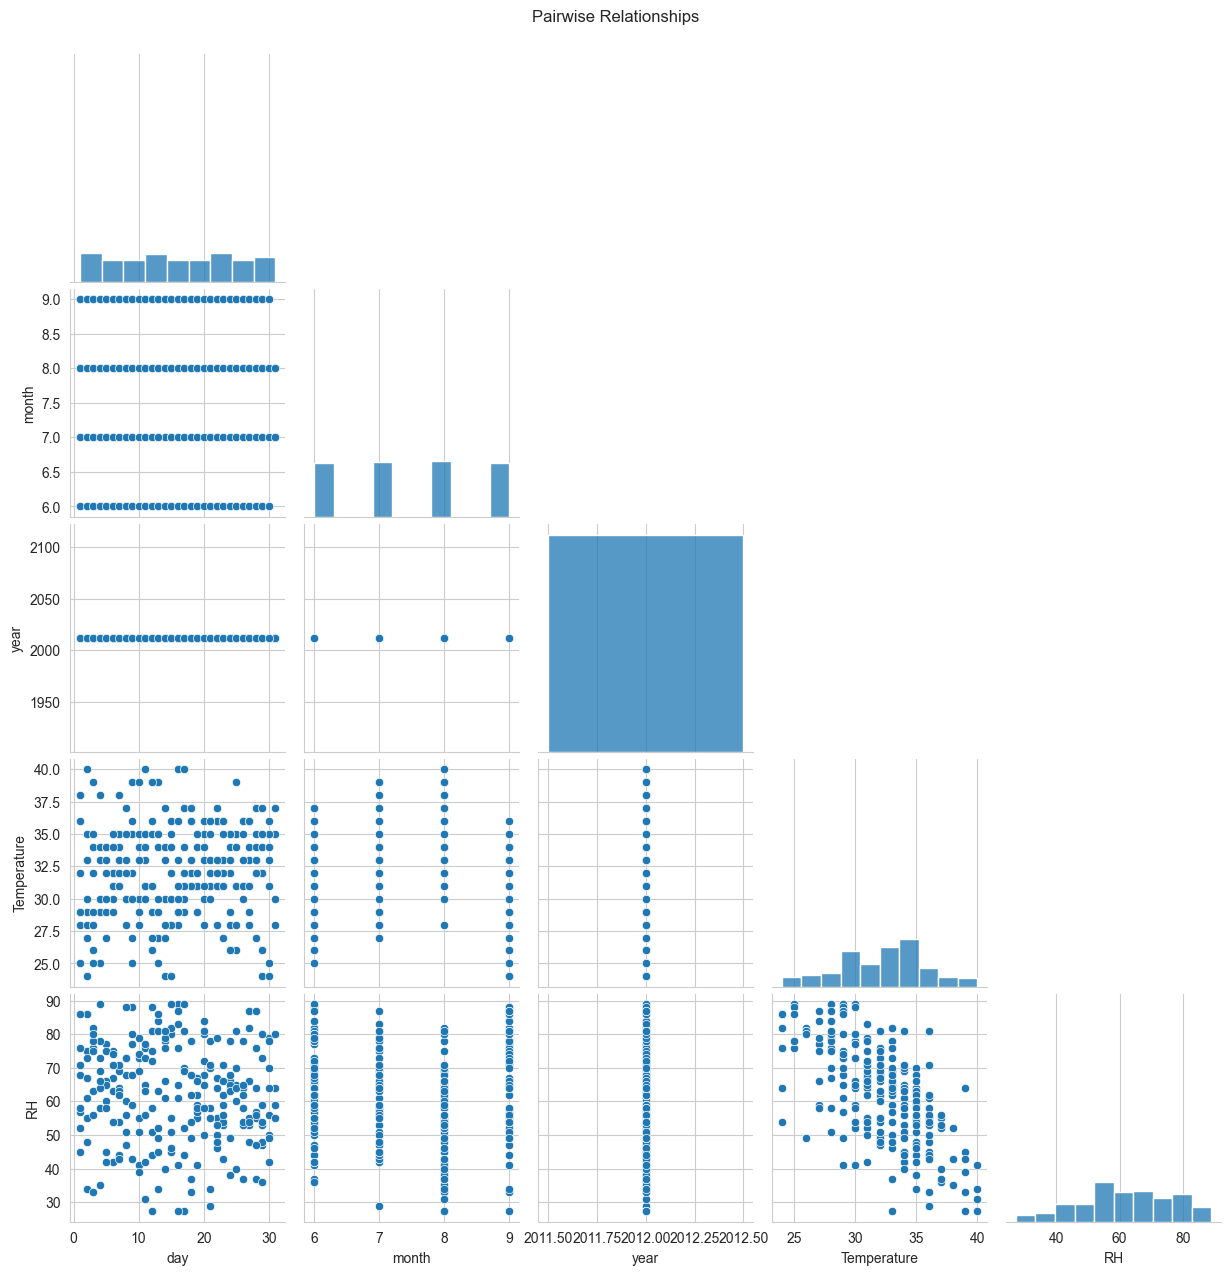

Ridge optimal alpha: 0.001


c:\Users\ninic\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.234e+00, tolerance: 9.100e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\ninic\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.739e+00, tolerance: 9.206e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\ninic\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

Lasso optimal alpha: 0.001
OLS | MSE: 0.17, MAE: 0.31, R2: 0.994
Ridge | MSE: 0.30, MAE: 0.34, R2: 0.990
Lasso | MSE: 0.18, MAE: 0.29, R2: 0.994
Ridge CV R2: 0.978 ± 0.009
             feature       coef
86          FFMC ISI  29.548000
10               ISI -11.247306
46          year ISI -11.247306
74            Ws BUI   8.883326
84          FFMC DMC   8.436713
71            Ws DMC  -6.909271
54   Temperature DMC   6.421245
99           ISI BUI   5.699850
98             ISI^2  -4.914761
102       BUI Region   4.207938
Best Ridge pipeline saved.


c:\Users\ninic\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.057e+00, tolerance: 1.171e+00
  model = cd_fast.enet_coordinate_descent(


In [ ]:

# Expert Analysis: Predicting Fire Weather Index (FWI)
# ## Objective:
# I will develop a robust workflow to predict FWI using dynamic feature handling and linear models.


## 1. Imports & Settings

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import pickle

sns.set_style('whitegrid')
np.random.seed(42)


## 2. Load & Inspect Data

# %%
# Update path to your local CSV file
path = r'D:\ninic\Algerian_forest_fires_cleaned.csv'
df = pd.read_csv(path)
print(df.info())
print(df.head())

# Automatically drop any non-numeric columns
num_df = df.select_dtypes(include=[np.number]).copy()
if num_df.shape[1] < df.shape[1]:
    removed = set(df.columns) - set(num_df.columns)
    print(f"Dropped non-numeric columns: {removed}")

 
## 3. Cleaning & Outlier Handling

# %%
print("Missing values per column:\n", num_df.isnull().sum())
num_df = num_df.dropna()
for col in num_df.columns:
    low, high = num_df[col].quantile([0.01, 0.99])
    num_df[col] = num_df[col].clip(low, high)

 
## 4. Define Features and Target

# %%
y = num_df['FWI']
X = num_df.drop(columns=['FWI'])

 
## 5. Exploratory Data Analysis

# %%
plt.figure(figsize=(8,4))
plt.hist(y, bins=30, edgecolor='k')
plt.title('FWI Distribution')
plt.xlabel('FWI')
plt.ylabel('Count')
plt.show()

# %%
corr_matrix = num_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric Feature Correlation')
plt.show()

# %%
# Pairwise plots for first five numeric features
demo_cols = num_df.columns.tolist()[:5]
sns.pairplot(num_df[demo_cols], corner=True)
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

 
## 6. Train-Test Split

# %%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

 
## 7. Build Pipelines & Hyperparameter Tuning

# %%
def build_pipeline(model):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scale', StandardScaler()),
        ('reg', model)
    ])

pipelines = {
    'OLS': build_pipeline(LinearRegression()),
    'Ridge': build_pipeline(Ridge()),
    'Lasso': build_pipeline(Lasso(max_iter=10000))
}
param_grids = {
    'Ridge': {'reg__alpha': np.logspace(-3, 3, 10)},
    'Lasso': {'reg__alpha': np.logspace(-3, 3, 10)}
}
best_models = {}
for name, pipe in pipelines.items():
    if name in param_grids:
        grid = GridSearchCV(pipe, param_grids[name], cv=5, scoring='r2')
        grid.fit(X_train, y_train)
        best_models[name] = grid.best_estimator_
        print(f"{name} optimal alpha: {grid.best_params_['reg__alpha']}")
    else:
        pipe.fit(X_train, y_train)
        best_models[name] = pipe

 
## 8. Model Evaluation

# %%
def summarize(name, model):
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name} | MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.3f}")

for key, mdl in best_models.items():
    summarize(key, mdl)

cv_ridge = cross_val_score(best_models['Ridge'], X, y, cv=5, scoring='r2')
print(f"Ridge CV R2: {cv_ridge.mean():.3f} ± {cv_ridge.std():.3f}")

 
## 9. Feature Importance

# %%
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X)
feat_names = poly.get_feature_names_out(X.columns)
ridge_coefs = best_models['Ridge'].named_steps['reg'].coef_
fi_df = pd.DataFrame({'feature': feat_names, 'coef': ridge_coefs})
fi_df = fi_df.reindex(fi_df.coef.abs().sort_values(ascending=False).index)
print(fi_df.head(10))

 
## 10. Serialize Best Model

# %%
with open('best_ridge_fwi.pkl', 'wb') as f:
    pickle.dump(best_models['Ridge'], f)
print('Best Ridge pipeline saved.')

 
## 11. Conclusions

# - Polynomial expansion with regularization improved R2.
# - Next steps: feature selection, ensemble models, or automated ML approaches.
